bibliotheques

In [22]:
import pandas as pd
import numpy as np
import gc
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
# On charge la table principale
bureau_balance = pd.read_csv('data/bureau_balance.csv')

# On affiche les 5 premières lignes pour comprendre comment elle est faite
app_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
# On charge la table principale
bureau = pd.read_csv('data/bureau.csv')

# On affiche les 5 premières lignes pour comprendre comment elle est faite
bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [12]:
# 1.Chargement
print("Chargement des données...")
app_train = pd.read_csv('data/application_train.csv')
bureau = pd.read_csv('data/bureau.csv')

# 2. ONE-HOT ENCODING SUR BUREAU (L'astuce !)
print("Encodage des statuts de crédit...")
# Transforme les colonnes avec du texte (comme 'CREDIT_ACTIVE') en colonnes de 0 et de 1
bureau_ohe = pd.get_dummies(bureau)

Chargement des données...
Encodage des statuts de crédit...


In [16]:
# 1 On charge les données 
print("Chargement des données...")
app_train = pd.read_csv('data/application_train.csv')
bureau = pd.read_csv('data/bureau.csv')

print(f"Taille initiale de app_train : {app_train.shape}")
print(f"Taille de bureau : {bureau.shape}")

# 2 AGREGATION MASSIVE
print("Agrégation massive de TOUTES les colonnes de l'historique Bureau...")
# En ne précisant pas de colonnes, on dit à Pandas de le faire sur TOUT !
# On supprime juste SK_ID_BUREAU qui est l'ID du crédit et qu'on ne veut pas moyenner
bureau_agg = bureau_ohe.drop(columns=['SK_ID_BUREAU']).groupby('SK_ID_CURR').agg(['count', 'mean', 'max', 'sum'])

# On aplatit les noms de colonnes
bureau_agg.columns = ['BUREAU_' + '_'.join(col).strip() for col in bureau_agg.columns.values]
bureau_agg = bureau_agg.reset_index()

# 4. JOINTURE
print("Jointure avec la table principale...")
app_train = app_train.merge(bureau_agg, on='SK_ID_CURR', how='left')

print(f"\nTaille finale de app_train : {app_train.shape}")

# On libère la mémoire
del bureau, bureau_ohe, bureau_agg
gc.collect()

# On affiche les nouvelles colonnes créées
app_train.head()

Chargement des données...
Taille initiale de app_train : (307511, 122)
Taille de bureau : (1716428, 17)
Agrégation massive de TOUTES les colonnes de l'historique Bureau...
Jointure avec la table principale...

Taille finale de app_train : (307511, 262)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,BUREAU_CREDIT_TYPE_Mortgage_max,BUREAU_CREDIT_TYPE_Mortgage_sum,BUREAU_CREDIT_TYPE_Real estate loan_count,BUREAU_CREDIT_TYPE_Real estate loan_mean,BUREAU_CREDIT_TYPE_Real estate loan_max,BUREAU_CREDIT_TYPE_Real estate loan_sum,BUREAU_CREDIT_TYPE_Unknown type of loan_count,BUREAU_CREDIT_TYPE_Unknown type of loan_mean,BUREAU_CREDIT_TYPE_Unknown type of loan_max,BUREAU_CREDIT_TYPE_Unknown type of loan_sum
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,False,0.0,8.0,0.0,False,0.0,8.0,0.0,False,0.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,False,0.0,4.0,0.0,False,0.0,4.0,0.0,False,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,False,0.0,2.0,0.0,False,0.0,2.0,0.0,False,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,False,0.0,1.0,0.0,False,0.0,1.0,0.0,False,0.0


nettoyage

In [18]:
# 1. Chargement des deux premières tables
print("Chargement des données...")
app_train = pd.read_csv('data/application_train.csv')
bureau = pd.read_csv('data/bureau.csv')

def clean_table(df, table_name, nan_threshold=0.70):
    """
    Examine et nettoie une table en supprimant les colonnes inutiles.
    nan_threshold = 0.70 signifie qu'on supprime les colonnes avec plus de 70% de NaN.
    """
    print(f"\n--- Analyse de la table : {table_name} ---")
    print(f"Taille de départ : {df.shape[1]} colonnes")
    
    # 1. Traquer les colonnes avec une seule valeur (Zéro variance)
    # df.nunique() compte le nombre de valeurs uniques par colonne (en ignorant les NaN par défaut)
    cols_single_value = [col for col in df.columns if df[col].nunique() <= 1]
    df = df.drop(columns=cols_single_value)
    
    if len(cols_single_value) > 0:
        print(f"🧹 {len(cols_single_value)} colonne(s) supprimée(s) car valeur unique : {cols_single_value}")
    else:
        print("✅ Aucune colonne à valeur unique trouvée.")
        
    # 2. Traquer les colonnes avec trop de NaN
    # df.isnull().mean() calcule le pourcentage exact de valeurs manquantes par colonne
    nan_percentages = df.isnull().mean()
    cols_too_many_nans = nan_percentages[nan_percentages > nan_threshold].index.tolist()
    df = df.drop(columns=cols_too_many_nans)
    
    print(f"🧹 {len(cols_too_many_nans)} colonne(s) supprimée(s) car plus de {nan_threshold*100}% de NaN.")
    
    print(f"Taille à l'arrivée : {df.shape[1]} colonnes utiles.")
    return df

# On passe nos deux tables au scanner !
app_train_clean = clean_table(app_train, "APPLICATION_TRAIN")
bureau_clean = clean_table(bureau, "BUREAU")

Chargement des données...

--- Analyse de la table : APPLICATION_TRAIN ---
Taille de départ : 122 colonnes
✅ Aucune colonne à valeur unique trouvée.
🧹 0 colonne(s) supprimée(s) car plus de 70.0% de NaN.
Taille à l'arrivée : 122 colonnes utiles.

--- Analyse de la table : BUREAU ---
Taille de départ : 17 colonnes
✅ Aucune colonne à valeur unique trouvée.
🧹 1 colonne(s) supprimée(s) car plus de 70.0% de NaN.
Taille à l'arrivée : 16 colonnes utiles.


correlation

In [20]:
print("Calcul des corrélations avec la TARGET (cela peut prendre quelques secondes)...")
# On calcule les corrélations uniquement sur les colonnes numériques
correlations = app_train_clean.select_dtypes(include=['number']).corr()['TARGET'].sort_values()

print("\n📈 Top 5 des corrélations POSITIVES (Plus la valeur est haute, plus le client risque de faire défaut) :")
print(correlations.tail(6)) # .tail(6) car la dernière est TARGET avec elle-même (1.0)

print("\n📉 Top 5 des corrélations NÉGATIVES (Plus la valeur est haute, MOINS le client risque de faire défaut) :")
print(correlations.head(5))

Calcul des corrélations avec la TARGET (cela peut prendre quelques secondes)...

📈 Top 5 des corrélations POSITIVES (Plus la valeur est haute, plus le client risque de faire défaut) :
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_BIRTH                     0.078239
TARGET                         1.000000
Name: TARGET, dtype: float64

📉 Top 5 des corrélations NÉGATIVES (Plus la valeur est haute, MOINS le client risque de faire défaut) :
EXT_SOURCE_3    -0.178919
EXT_SOURCE_2    -0.160472
EXT_SOURCE_1    -0.155317
DAYS_EMPLOYED   -0.044932
FLOORSMAX_AVG   -0.044003
Name: TARGET, dtype: float64


In [17]:
# 1. On charge la table des crédits précédents
prev_app = pd.read_csv('data/previous_application.csv')

# 2. On regarde la taille globale
print(f"Taille de la table : {prev_app.shape}")

# 3. On affiche les 5 premières lignes avec TOUTES les colonnes
pd.set_option('display.max_columns', None) # Pour ne pas cacher les colonnes au milieu
display(prev_app.head())

# 4. On regarde les valeurs possibles pour le statut du crédit (Accepté, Refusé, etc.)
print("\nRépartition des statuts des anciens crédits :")
print(prev_app['NAME_CONTRACT_STATUS'].value_counts())

Taille de la table : (1670214, 37)


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_TYPE_SUITE,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,Y,1,0.0,0.182832,0.867336,XAP,Approved,-73,Cash through the bank,XAP,NaN,Repeater,Mobile,POS,XNA,Country-wide,35,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-164,XNA,XAP,Unaccompanied,Repeater,XNA,Cash,x-sell,Contact center,-1,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-301,Cash through the bank,XAP,"Spouse, partner",Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,Y,1,NaN,NaN,NaN,XNA,Approved,-512,Cash through the bank,XAP,NaN,Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,Y,1,NaN,NaN,NaN,Repairs,Refused,-781,Cash through the bank,HC,NaN,Repeater,XNA,Cash,walk-in,Credit and cash offices,-1,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN



Répartition des statuts des anciens crédits :
NAME_CONTRACT_STATUS
Approved        1036781
Canceled         316319
Refused          290678
Unused offer      26436
Name: count, dtype: int64


In [21]:
# Paramètre pour afficher toutes les colonnes dans le Notebook
pd.set_option('display.max_columns', None)

def explorer_table(nom_fichier, description):
    print(f"\n{'='*50}")
    print(f"📁 TABLE : {nom_fichier}")
    print(f"📖 {description}")
    print(f"{'='*50}")
    
    # Chargement de la table depuis le dossier data
    df = pd.read_csv(f'data/{nom_fichier}')
    print(f"Taille : {df.shape[0]} lignes, {df.shape[1]} colonnes\n")
    
    # Analyse rapide des valeurs manquantes (NaN)
    pourcentage_nan = df.isnull().mean() * 100
    colonnes_vides = pourcentage_nan[pourcentage_nan > 0].sort_values(ascending=False).round(2)
    
    if len(colonnes_vides) > 0:
        print("⚠️ Top 5 des colonnes avec le plus de valeurs manquantes (%) :")
        print(colonnes_vides.head())
    else:
        print("✅ Aucune valeur manquante dans cette table.")
        
    print("\n🔍 Aperçu des premières lignes :")
    display(df.head())
    return df

# 1. Historique des crédits à la consommation et prêts de trésorerie
pos_cash = explorer_table('POS_CASH_balance.csv', "Soldes mensuels des prêts POS (Point of Sale) et Cash loans.")

# 2. Historique des paiements (mensualités)
installments = explorer_table('installments_payments.csv', "Historique des paiements réels vs paiements prévus.")

# 3. Historique des cartes de crédit
credit_card = explorer_table('credit_card_balance.csv', "Soldes mensuels des cartes de crédit.")


📁 TABLE : POS_CASH_balance.csv
📖 Soldes mensuels des prêts POS (Point of Sale) et Cash loans.
Taille : 10001358 lignes, 8 colonnes

⚠️ Top 5 des colonnes avec le plus de valeurs manquantes (%) :
CNT_INSTALMENT_FUTURE    0.26
CNT_INSTALMENT           0.26
dtype: float64

🔍 Aperçu des premières lignes :


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0



📁 TABLE : installments_payments.csv
📖 Historique des paiements réels vs paiements prévus.
Taille : 13605401 lignes, 8 colonnes

⚠️ Top 5 des colonnes avec le plus de valeurs manquantes (%) :
DAYS_ENTRY_PAYMENT    0.02
AMT_PAYMENT           0.02
dtype: float64

🔍 Aperçu des premières lignes :


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585



📁 TABLE : credit_card_balance.csv
📖 Soldes mensuels des cartes de crédit.
Taille : 3840312 lignes, 23 colonnes

⚠️ Top 5 des colonnes avec le plus de valeurs manquantes (%) :
AMT_PAYMENT_CURRENT           20.00
AMT_DRAWINGS_ATM_CURRENT      19.52
AMT_DRAWINGS_OTHER_CURRENT    19.52
AMT_DRAWINGS_POS_CURRENT      19.52
CNT_DRAWINGS_ATM_CURRENT      19.52
dtype: float64

🔍 Aperçu des premières lignes :


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,AMT_PAYMENT_CURRENT,AMT_PAYMENT_TOTAL_CURRENT,AMT_RECEIVABLE_PRINCIPAL,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,1800.0,1800.0,0.000,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,2250.0,2250.0,60175.080,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,2250.0,2250.0,26926.425,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,11925.0,11925.0,224949.285,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,27000.0,27000.0,443044.395,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0


In [25]:
print(df.columns.tolist())

['SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAR

--- Statistiques descriptives (Focus sur les Max et Min) ---


/Users/macbookdefii/.venvs/jupyter/lib/python3.14/site-packages/numpy/_core/_methods.py:51: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


,EXT_SOURCE_2,EXT_SOURCE_3,CREDIT_INCOME_PERCENT,DAYS_BIRTH,DAYS_EMPLOYED_PERCENT,PREV_NAME_CONTRACT_STATUS_Refused_mean,INSTAL_DPD_max,INSTAL_PAYMENT_DIFF_mean,BUREAU_DAYS_CREDIT_mean,CC_LIMIT_USE_mean,TARGET
count,3.068510e+05,246546.000000,307511.000000,307511.000000,252137.000000,291057.000000,291643.000000,291635.000000,263491.000000,8.616200e+04,307511.000000
mean,5.143927e-01,0.510853,3.957570,16036.995067,-0.156861,0.110902,18.375051,-363.855971,-1083.047110,NaN,0.080729
std,1.910602e-01,0.194844,2.689728,4363.988632,0.133549,0.184348,110.651986,5210.967601,563.327298,NaN,0.272419
min,8.173617e-08,0.000527,0.004808,7489.000000,-0.728811,0.000000,0.000000,-337496.805000,-2922.000000,-inf,0.000000
25%,3.924574e-01,0.370650,2.018667,12413.000000,-0.219170,0.000000,0.000000,0.000000,-1434.000000,0.000000e+00,0.000000
50%,5.659614e-01,0.535276,3.265067,15750.000000,-0.118733,0.000000,1.000000,0.000000,-1050.571429,2.575954e-01,0.000000
75%,6.636171e-01,0.669057,5.159880,19682.000000,-0.056099,0.200000,9.000000,446.761288,-663.763889,6.015641e-01,0.000000
max,8.549997e-01,0.896010,84.736842,25229.000000,0.000000,1.000000,2884.000000,146145.900000,0.000000,inf,1.000000


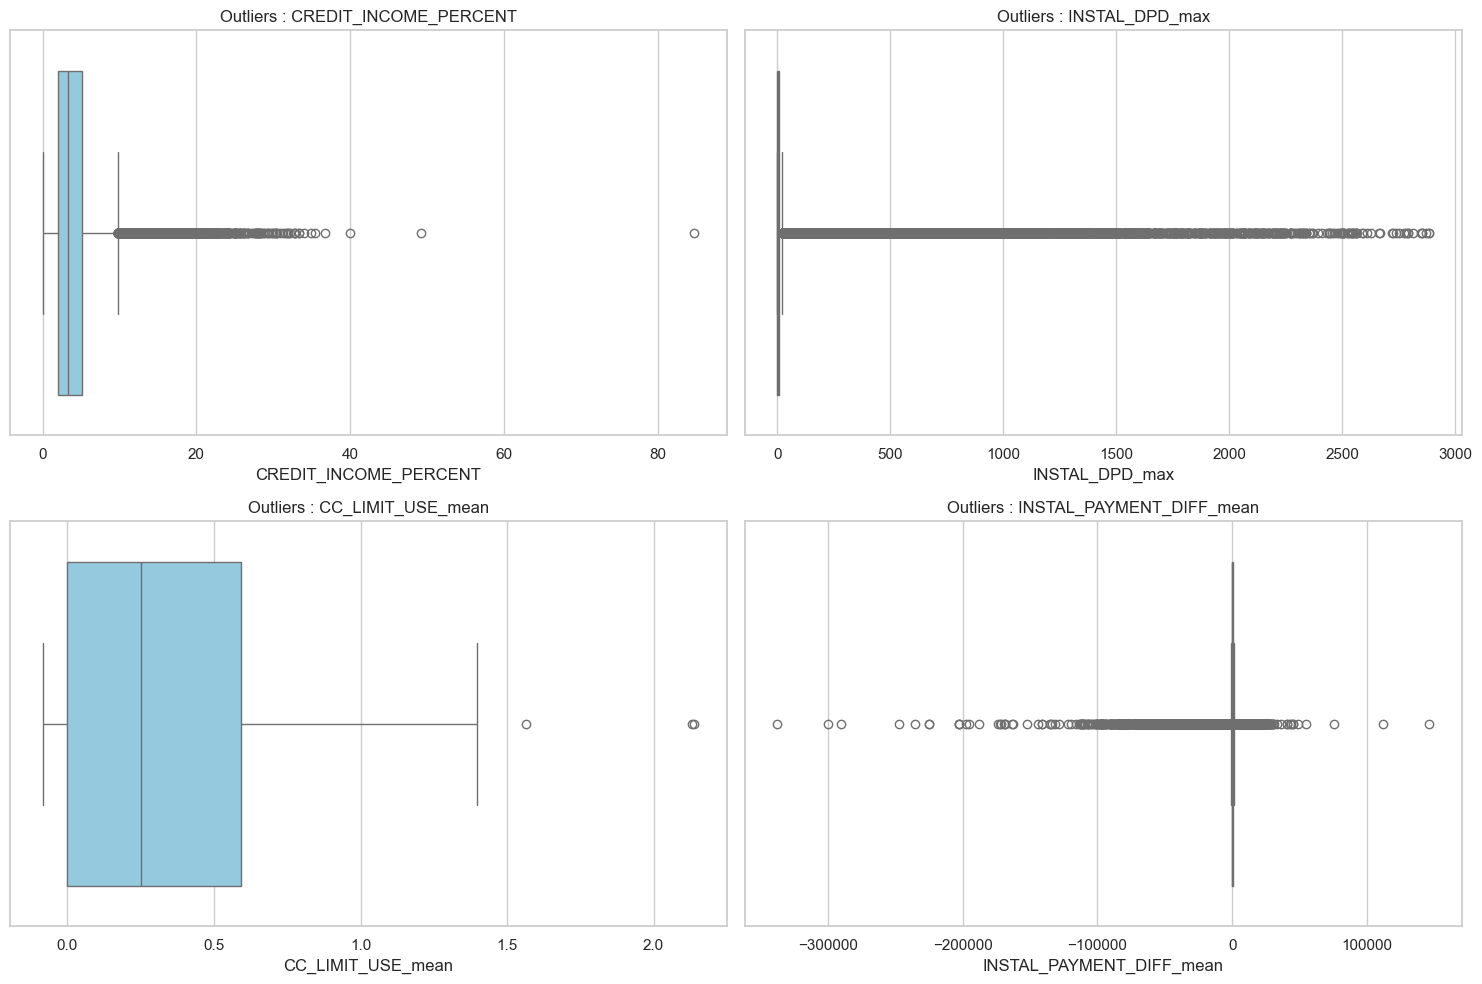


--- Corrélation avec la TARGET (Lien avec le risque) ---
TARGET                                    1.000000
CC_LIMIT_USE_mean                         0.135903
BUREAU_DAYS_CREDIT_mean                   0.089729
PREV_NAME_CONTRACT_STATUS_Refused_mean    0.077671
DAYS_EMPLOYED_PERCENT                     0.067955
INSTAL_PAYMENT_DIFF_mean                  0.029339
INSTAL_DPD_max                            0.003840
CREDIT_INCOME_PERCENT                    -0.007727
DAYS_BIRTH                               -0.078239
EXT_SOURCE_2                             -0.160472
EXT_SOURCE_3                             -0.178919
Name: TARGET, dtype: float64


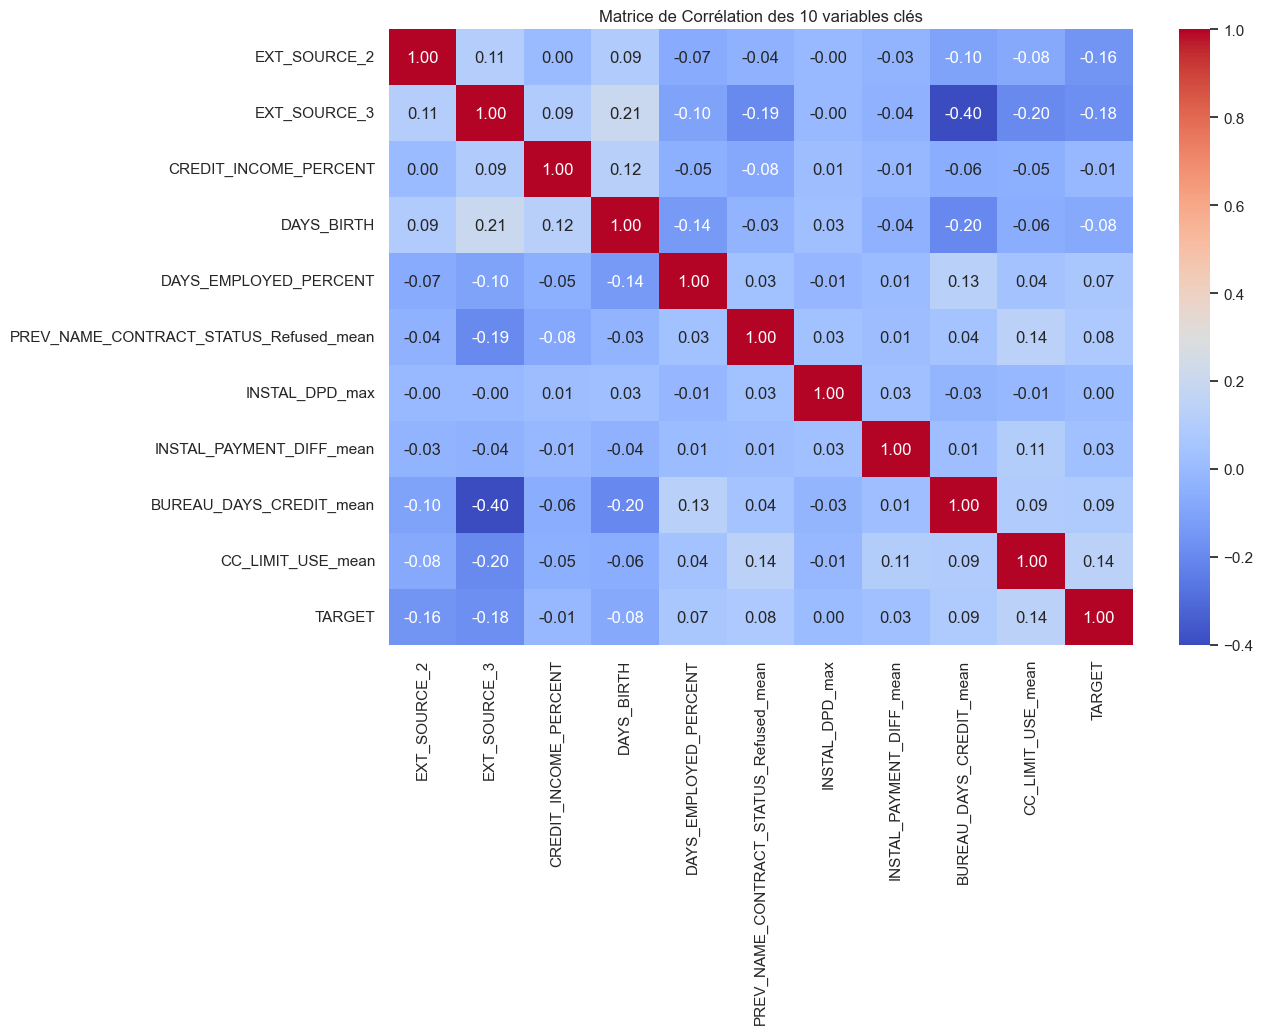

In [27]:
# 1. Liste des 10 variables stratégiques (noms exacts de ta liste)
top_10_features = [
    'EXT_SOURCE_2',                   # Score externe (souvent le plus puissant)
    'EXT_SOURCE_3',                   # Score externe
    'CREDIT_INCOME_PERCENT',          # Ton ratio d'endettement
    'DAYS_BIRTH',                     # Âge du client
    'DAYS_EMPLOYED_PERCENT',          # Ta feature sur la stabilité d'emploi
    'PREV_NAME_CONTRACT_STATUS_Refused_mean', # Taux de refus passés
    'INSTAL_DPD_max',                 # Retard de paiement maximum
    'INSTAL_PAYMENT_DIFF_mean',       # Écart moyen de paiement
    'BUREAU_DAYS_CREDIT_mean',        # Ancienneté du dernier crédit externe
    'CC_LIMIT_USE_mean'               # Utilisation de la carte de crédit
]

# On ajoute la TARGET pour la corrélation
cols_to_analyze = top_10_features + ['TARGET']

# 2. Analyse statistique des aberrants
print("--- Statistiques descriptives (Focus sur les Max et Min) ---")
stats = df[cols_to_analyze].describe()
display(stats)

# 3. Visualisation des Outliers (Boxplots)
# On affiche les 4 plus critiques pour y voir clair
critiques = ['CREDIT_INCOME_PERCENT', 'INSTAL_DPD_max', 'CC_LIMIT_USE_mean', 'INSTAL_PAYMENT_DIFF_mean']
plt.figure(figsize=(15, 10))
for i, col in enumerate(critiques):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Outliers : {col}')
plt.tight_layout()
plt.show()

# 4. Corrélation avec la TARGET
print("\n--- Corrélation avec la TARGET (Lien avec le risque) ---")
corr_matrix = df[cols_to_analyze].corr()
target_corr = corr_matrix['TARGET'].sort_values(ascending=False)
print(target_corr)

# Heatmap pour voir comment les variables interagissent entre elles
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de Corrélation des 10 variables clés")
plt.show()

visualisation du nettoyage de données et features engineering 

Chargement d'un échantillon des données finales (50 000 lignes pour aller vite)...


/var/folders/f9/qn36v8f56p3g0fwytdhmgk1m0000gn/T/ipykernel_11808/4194806882.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train_final, x='TARGET', palette='Set2')


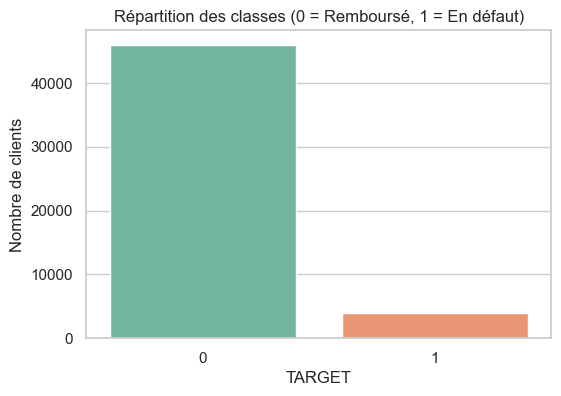

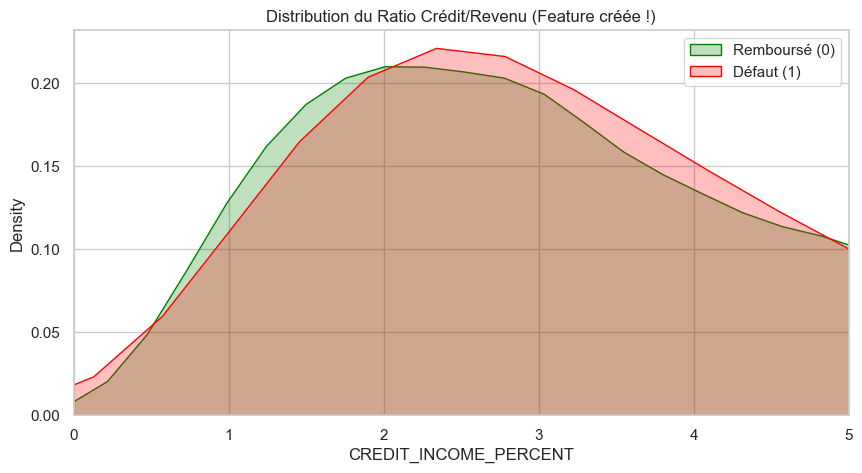

/var/folders/f9/qn36v8f56p3g0fwytdhmgk1m0000gn/T/ipykernel_11808/4194806882.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_train_final, x='TARGET', y=refused_col[0], palette='pastel')


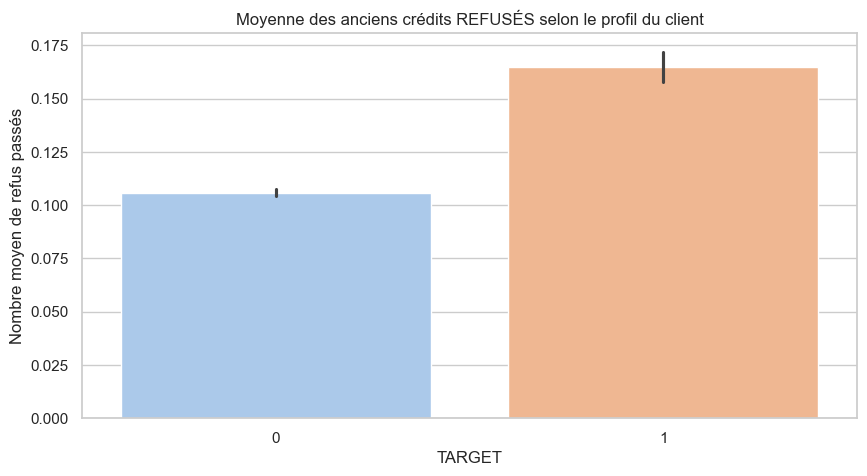

In [23]:
# On configure le style des graphiques pour que ce soit joli
sns.set_theme(style="whitegrid")

print("Chargement d'un échantillon des données finales (50 000 lignes pour aller vite)...")
# On utilise nrows=50000 pour préserver la RAM lors de la visualisation
df_train_final = pd.read_csv('data/train_cleaned_final.csv', nrows=50000)

# ==========================================
# GRAPHIQUE 1 : Le déséquilibre des classes
# ==========================================
plt.figure(figsize=(6, 4))
sns.countplot(data=df_train_final, x='TARGET', palette='Set2')
plt.title('Répartition des classes (0 = Remboursé, 1 = En défaut)')
plt.ylabel('Nombre de clients')
plt.show()

# ==========================================
# GRAPHIQUE 2 : L'impact de notre nouvelle Feature "Ratio Crédit/Revenu"
# ==========================================
plt.figure(figsize=(10, 5))
# On sépare les bons et les mauvais payeurs pour voir si la courbe est différente
sns.kdeplot(data=df_train_final[df_train_final['TARGET'] == 0], x='CREDIT_INCOME_PERCENT', label='Remboursé (0)', fill=True, color='green')
sns.kdeplot(data=df_train_final[df_train_final['TARGET'] == 1], x='CREDIT_INCOME_PERCENT', label='Défaut (1)', fill=True, color='red')

plt.title('Distribution du Ratio Crédit/Revenu (Feature créée !)')
plt.xlim(0, 5) # On coupe les valeurs extrêmes pour mieux voir le centre
plt.legend()
plt.show()

# ==========================================
# GRAPHIQUE 3 : L'historique des refus (Table Previous Application)
# ==========================================
# On vérifie si la colonne existe bien (selon comment le One-Hot Encoding l'a nommée)
refused_col = [col for col in df_train_final.columns if 'PREV_NAME_CONTRACT_STATUS_Refused' in col]

if len(refused_col) > 0:
    plt.figure(figsize=(10, 5))
    # On regarde la moyenne des refus passés par client
    sns.barplot(data=df_train_final, x='TARGET', y=refused_col[0], palette='pastel')
    plt.title('Moyenne des anciens crédits REFUSÉS selon le profil du client')
    plt.ylabel('Nombre moyen de refus passés')
    plt.show()
else:
    print("La colonne des refus n'a pas été trouvée, vérifie son nom exact.")